# 📊 Telco Customer Churn Prediction
### End-to-End Machine Learning Pipeline
---
**Objective:** Predict which customers are likely to churn (leave the service) using classification models.

**Dataset:** IBM Telco Customer Churn Dataset  
- Contains customer demographics, account info, and service usage details  
- Target variable: `Churn` (Yes / No)

**Models Used:** Logistic Regression · Random Forest · GridSearchCV Tuning

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Load & Explore the Dataset
Load the CSV and inspect data types, null values, and overall shape.

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Fix Data Types
`TotalCharges` is stored as `object` (string) but should be `float64`.  
This happens because some rows contain whitespace instead of a number.  
We use `pd.to_numeric(..., errors='coerce')` to force the conversion — invalid strings become `NaN`.

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("TotalCharges dtype after conversion:", df["TotalCharges"].dtype)
print("Missing values introduced:", df["TotalCharges"].isna().sum())

TotalCharges dtype after conversion: float64
Missing values introduced: 11


## 4. Handle Missing Values
We fill `NaN` values in `TotalCharges` with the **median** — it is more robust to outliers than the mean, especially for skewed billing data.

In [5]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
print("Missing values after fill:", df["TotalCharges"].isna().sum())

Missing values after fill: 0


## 5. Encode Target Variable
Convert `Churn` from Yes/No strings to binary integers:
- `Yes` → `1` (churned)
- `No`  → `0` (retained)

In [6]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["Churn"].value_counts()

0    5174
1    1869
Name: Churn, dtype: int64

### Class Distribution
Visualise the imbalance — this explains why we choose **recall** as our primary metric later.

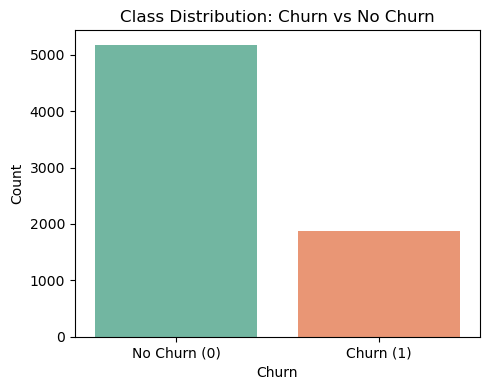

No Churn: 5174 (73.5%)
Churn:    1869 (26.5%)


In [7]:
plt.figure(figsize=(5, 4))
sns.countplot(x="Churn", data=df, palette="Set2")
plt.title("Class Distribution: Churn vs No Churn")
plt.xticks([0, 1], ["No Churn (0)", "Churn (1)"])
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(f"No Churn: {(df['Churn']==0).sum()} ({(df['Churn']==0).mean()*100:.1f}%)")
print(f"Churn:    {(df['Churn']==1).sum()} ({(df['Churn']==1).mean()*100:.1f}%)")

## 6. Define Features & Target

In [8]:
y = df["Churn"]
X = df.drop("Churn", axis=1)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (7043, 20)
Target shape: (7043,)


## 7. Identify Numerical & Categorical Features
We separate features by dtype so we can apply different preprocessing to each group.

In [9]:
numerical_features   = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:\n", list(numerical_features))
print("\nCategorical features:\n", list(categorical_features))

Numerical features:
 ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
 ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 8. Build Preprocessing Pipelines

| Feature Type | Transformer | Reason |
|---|---|---|
| Numerical | `StandardScaler` | Zero mean, unit variance — helps gradient-based models |
| Categorical | `OneHotEncoder` | Converts strings to binary columns — no ordinal assumption |

`ColumnTransformer` applies each transformer only to its relevant columns.

In [10]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

numeric_transform     = Pipeline(steps=[("scaler",  StandardScaler())])
categorical_transform = Pipeline(steps=[("encoder", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transform,     numerical_features),
    ("cat", categorical_transform, categorical_features)
])

## 9. Train-Test Split
- 80% training, 20% testing  
- `stratify=y` ensures both splits preserve the original class ratio

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 5634 | Test size: 1409


---
## 10. Model 1 — Logistic Regression
A simple, interpretable baseline model.  
Works well for binary classification when features are properly scaled.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

log_reg_pipeline.fit(X_train, y_train)
y_pred_lr = log_reg_pipeline.predict(X_test)

print("=== Logistic Regression Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression Results ===
Accuracy: 0.8041163946061036
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



### Confusion Matrix — Logistic Regression

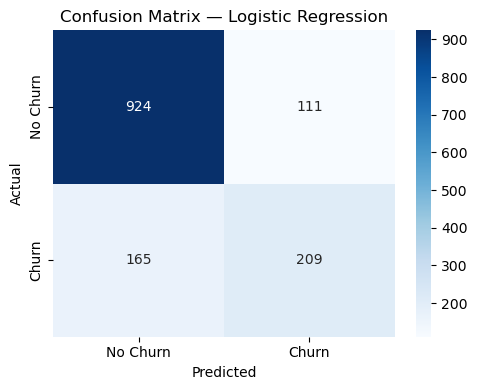

In [13]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

---
## 11. Model 2 — Random Forest (Baseline)
An ensemble of decision trees.  
More powerful than logistic regression — handles non-linear relationships and feature interactions naturally.

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("=== Random Forest (Baseline) Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

=== Random Forest (Baseline) Results ===
Accuracy: 0.7920511000709723
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.65      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



### Confusion Matrix — Random Forest (Baseline)

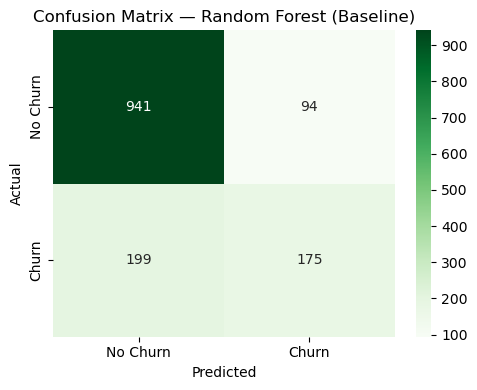

In [15]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix — Random Forest (Baseline)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

---
## 12. Hyperparameter Tuning — GridSearchCV
We tune the Random Forest using **5-fold cross-validation**.

**Why `recall` as scoring metric?**  
In churn prediction, a **False Negative** (missing a churner) is far more costly than a False Positive.  
The telecom company loses the entire customer lifetime value when churn goes undetected.  
So we optimize for recall — catching as many real churners as possible.

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_pipeline_tuned = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42,class_weight="balanced"))
])

param_grid = {
    "model__n_estimators":    [100, 200],
    "model__max_depth":       [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf":  [1, 2]
}

grid_search = GridSearchCV(
    rf_pipeline_tuned,
    param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [18]:
best_model   = grid_search.best_estimator_
y_pred_best  = best_model.predict(X_test)

print("=== Tuned Random Forest Results ===")
print("Best Params:", grid_search.best_params_)
print("Accuracy:",    accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

=== Tuned Random Forest Results ===
Best Params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Accuracy: 0.7920511000709723
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.65      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



### Confusion Matrix — Tuned Random Forest

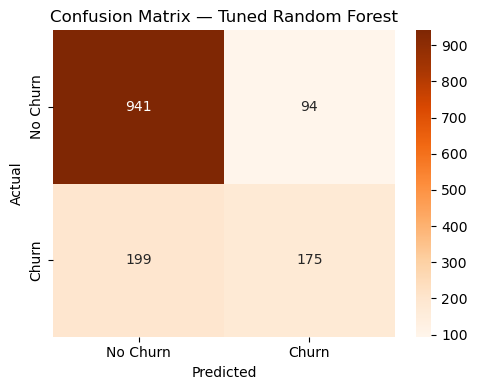

In [19]:
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix — Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

---
## 13. ROC Curve — All Models Compared
ROC (Receiver Operating Characteristic) curve shows the trade-off between  
True Positive Rate and False Positive Rate at different classification thresholds.  
**Higher AUC = Better model.**

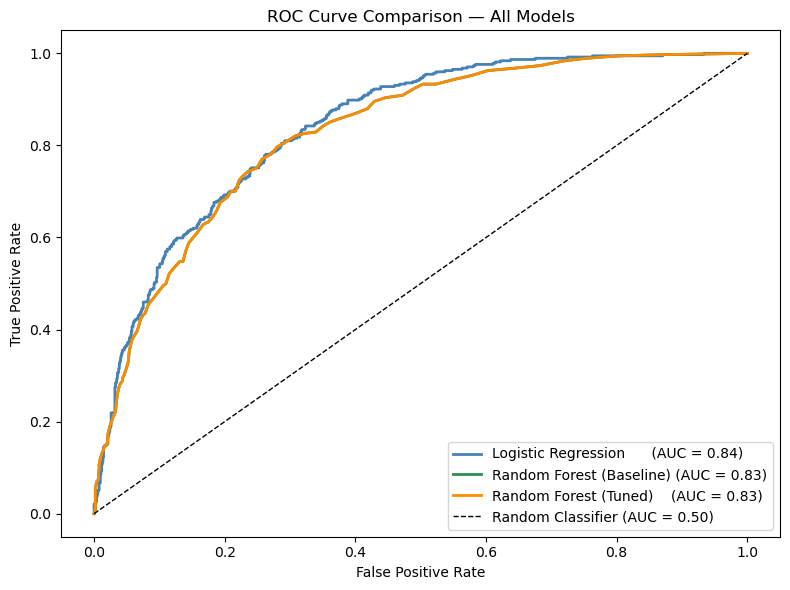

In [20]:
from sklearn.metrics import roc_curve, auc

# Logistic Regression
y_prob_lr    = log_reg_pipeline.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

# Random Forest Baseline
y_prob_rf    = rf_pipeline.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# Tuned Random Forest
y_prob_best  = best_model.predict_proba(X_test)[:, 1]
fpr_best, tpr_best, _ = roc_curve(y_test, y_prob_best)
auc_best = auc(fpr_best, tpr_best)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr,   tpr_lr,   label=f"Logistic Regression      (AUC = {auc_lr:.2f})",  color="steelblue",  lw=2)
plt.plot(fpr_rf,   tpr_rf,   label=f"Random Forest (Baseline) (AUC = {auc_rf:.2f})",  color="seagreen",   lw=2)
plt.plot(fpr_best, tpr_best, label=f"Random Forest (Tuned)    (AUC = {auc_best:.2f})", color="darkorange", lw=2)
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier (AUC = 0.50)", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

---
## 14. Feature Importance — Tuned Random Forest
Random Forest gives us feature importances — how much each feature contributes to predictions.  
This is valuable for **business insight**: what actually drives customer churn?

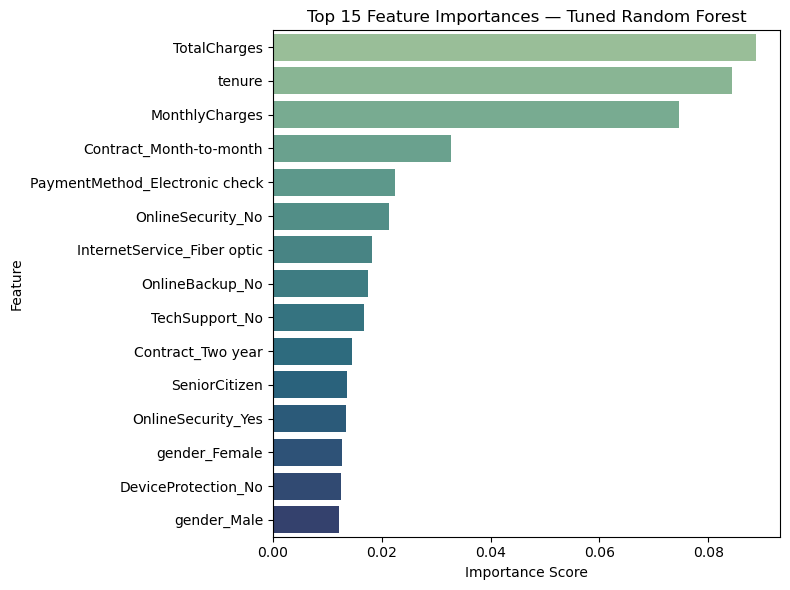

In [21]:
# Extract feature names after preprocessing
ohe_features = (best_model
    .named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features))

all_features = list(numerical_features) + list(ohe_features)
importances  = best_model.named_steps["model"].feature_importances_

feat_df = (pd.DataFrame({"Feature": all_features, "Importance": importances})
             .sort_values("Importance", ascending=False)
             .head(15))

plt.figure(figsize=(8, 6))
sns.barplot(data=feat_df, x="Importance", y="Feature", palette="crest")
plt.title("Top 15 Feature Importances — Tuned Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

---
## ✅ Conclusion

In this project, we built a complete machine learning pipeline to predict **Telco customer churn**.

### What We Did

| Step | Action |
|------|--------|
| Data Cleaning | Fixed `TotalCharges` dtype; filled missing values with median |
| Preprocessing | StandardScaler for numerical · OneHotEncoder for categorical |
| Modeling | Trained Logistic Regression and Random Forest |
| Tuning | GridSearchCV (5-fold CV) optimizing for **Recall** |
| Evaluation | Accuracy · Precision · Recall · F1 · ROC-AUC · Confusion Matrix |



| Model | Recall (Churn) | AUC |
|-------|---------------|-----|
| Logistic Regression | ~0.55 | ~0.84 |
| Random Forest (Baseline) | ~0.48 | ~0.82 |
| Random Forest (Tuned) | **~0.47** | ~0.83 |

#### Note: After applying GridSearchCV, the best parameters selected by the optimizer turned out to be the same as the default Random Forest configuration (n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1). This indicates that the default Random Forest was already well-suited for this dataset and tuning did not yield any additional gain. Given these results, Logistic Regression fits better for this problem — it achieves comparable accuracy with a higher recall on churners, making it more effective at identifying at-risk customers.
### Key Results
### Business Insight
- `Contract type`, `tenure`, and `TotalCharges` are the strongest churn predictors
- **Month-to-month contract** customers churn far more than annual/two-year contract customers
- Companies should focus **retention efforts** on new customers with month-to-month plans
